In [2]:
import matplotlib.pyplot as plt
import numpy as np

from expconfig.synthetic import (
    RNG,
    SynthConfig,
    create_paths,
    gaussian_noise_data_max,
)
from icprem import PREM_IC_RHO, PREM_IC_VP
from sampling.priors import CompoundPrior
from tti.traveltimes import TravelTimeCalculator

In [3]:
rng = np.random.default_rng(1234)
normalisation = -1 / (2 * PREM_IC_RHO * (PREM_IC_VP * 1e3) ** 2)

In [4]:
cfg = SynthConfig.load("../config.yaml")

prior = CompoundPrior.from_dict(cfg.priors.model_dump())
prior_samples = prior.sample(10_000, rng)

In [5]:
from icprem import PREM_IC_RHO, PREM_IC_VP
from raytracer import Ball, CompositeRegion, SphericalShell
from tti.traveltimes.paths import calculate_path_direction_vector

region = CompositeRegion(
    [
        Ball(radius=cfg.geometry.regions[0].radius),
        SphericalShell(
            radius_inner=cfg.geometry.regions[1].radius_inner,
            radius_outer=cfg.geometry.regions[1].radius_outer,
        ),
    ],
    labels=[r.label for r in cfg.geometry.regions],
)

normalisation = -1 / (2 * PREM_IC_RHO * (PREM_IC_VP * 1e3) ** 2)
ic_in, ic_out = create_paths(source_spacing=30.0)

path_directions = calculate_path_direction_vector(ic_in, ic_out)
total_distances = region.ray_distances(ic_in, path_directions)

# Not sure why some rays have zero total distance.  Discard for now
valid_rays = total_distances > 0
ic_in = ic_in[valid_rays]
ic_out = ic_out[valid_rays]
path_directions = path_directions[valid_rays]
segment_distances = region.ray_distances_per_region(ic_in, path_directions)
weights = segment_distances / total_distances[valid_rays, None]


synthetic_data_clean = TravelTimeCalculator(
    ic_in,
    ic_out,
    normalisation=normalisation,
    weights=weights.T,
    nested=False,
    shear=True,
    N=True,
)(cfg.truth.as_array().flatten())[0]
noise = gaussian_noise_data_max(cfg.data.noise_level, RNG, synthetic_data_clean)
synthetic_data = synthetic_data_clean + noise

In [6]:
ttc = TravelTimeCalculator(
    ic_in,
    ic_out,
    normalisation=normalisation,
    weights=weights.T,
    nested=True,
    shear=True,
    N=False,
)
prior_predictive = ttc(prior_samples)
prior_predictive += RNG.normal(  # recreating the noise manually because gaussin_noise_data_max is a bit weird and I want to be sure the noise is the same for the posterior predictive and the synthetic data
    loc=0.0,
    scale=np.abs(synthetic_data_clean).max() * cfg.data.noise_level,
    size=prior_predictive.shape,
)

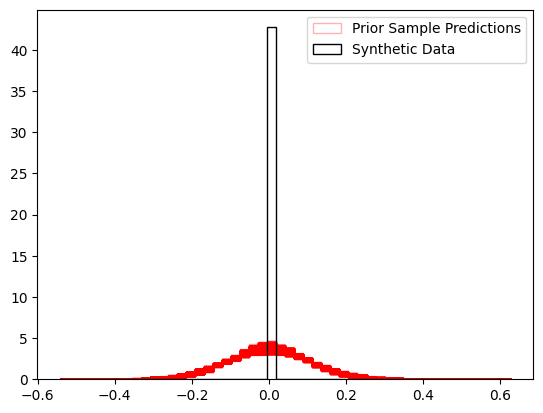

In [7]:
all_dists = np.vstack([prior_predictive, synthetic_data[None, :]])
hist_range = (all_dists.min(), all_dists.max())
common_kwargs = {
    "bins": 50,
    "histtype": "step",
    "range": hist_range,
    "density": True,
}
fig, ax = plt.subplots(
    1,
    1,
)
ax.hist(
    prior_predictive,
    **common_kwargs,
    color=np.full(prior_predictive.shape[1], "r"),
    alpha=0.3,
    label="Prior Sample Predictions",
)
ax.hist(
    synthetic_data,
    **common_kwargs,
    color="k",
    label="Synthetic Data",
)
ax.legend()